## Finding the most abundant complaint type for the first 2 months on 2024

In [1]:
def find_abundant_comp():
    # read the file output from borough_complaints.py sorted by complaint type
    # used the command line to sort the file
    with open("jan_feb_complaint_sorted.csv", "r") as f:
        f.readline()

        line = f.readline()
        
        max_ocur = 0
        max_comp = "undefined"

        cur_ocur = max_ocur
        cur_comp = max_comp
        
        while line:
            feats = line.split(',')

            # now counting the total occurances from new complaint type
            if feats[0] != cur_comp:

                # the previous compliant type is more abundant than the max
                if cur_ocur > max_ocur:
                    max_ocur = cur_ocur
                    max_comp = cur_comp
                    
                # prepare to start summing the occurances from the new complaint
                cur_comp = feats[0]
                cur_ocur = 0

            # sum all the complaint type ocurrances from each borough
            cur_ocur += int(feats[2])

            line = f.readline()

        return max_comp

In [3]:
res = find_abundant_comp()
print(f"The most abundant complaint type is {res}")

The most abundant complaint type is HEAT/HOT WATER


## Graphing the Occurrence of HEAT/HOT WATER Complaints per Borough

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

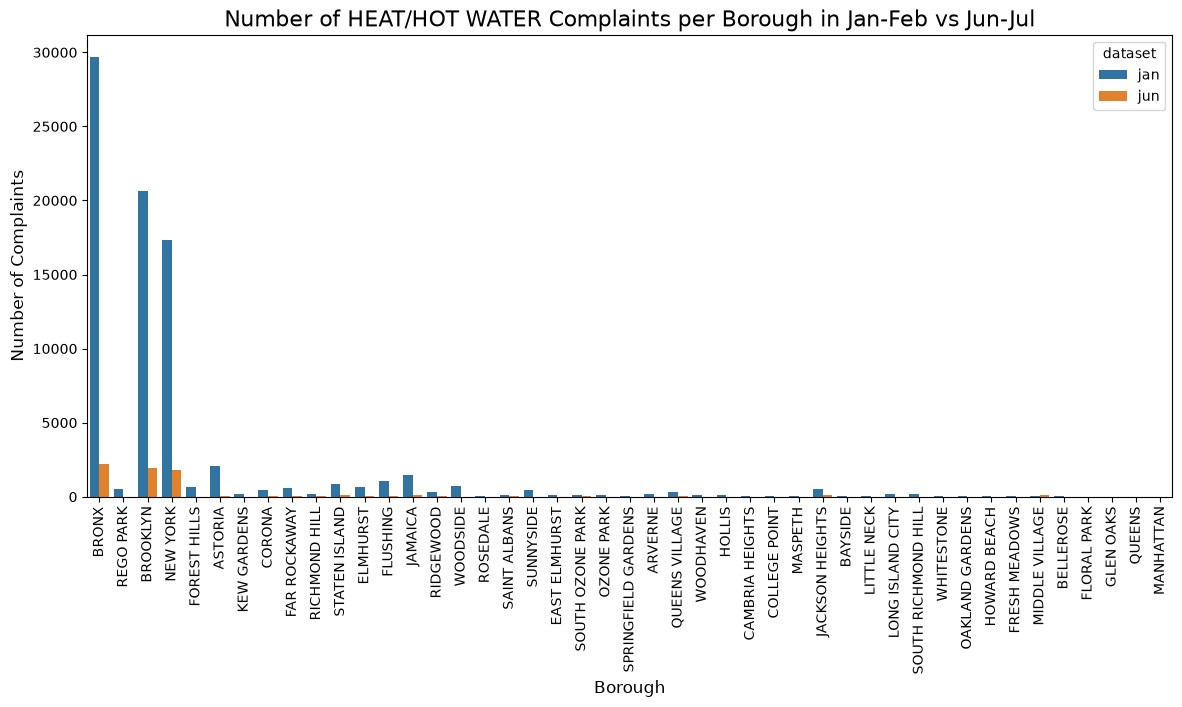

In [13]:
# turn csv files to dataframes and combine so they can be plotted together in the same graph
df_jan = pd.read_csv("jan_feb_heat_complaint.csv")
df_jun = pd.read_csv("jun_jul_heat_complaint.csv")

df_jan["dataset"] = "jan"
df_jun["dataset"] = "jun"

combined = pd.concat([df_jan, df_jun], ignore_index=True)

# making the plot
plt.figure(figsize=(14, 6))
plt.xticks(rotation=90)
plt.title("Number of HEAT/HOT WATER Complaints per Borough in Jan-Feb vs Jun-Jul", fontsize=16)
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)

sns.barplot(data=combined, x="borough", y="count", hue="dataset")

plt.show() 